In [1]:
from pathlib import Path
import sys

if "__file__" in globals():
    _here = Path(__file__).resolve()
else:
    _here = Path.cwd().resolve()

_root = next(p for p in [_here, *_here.parents] if (p / "config.py").exists())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from config import PROJECT_ROOT

In [2]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

from xgboost import XGBClassifier
import pyreadr

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
BASE_DIR = Path.cwd().parents[2]

TRAIN_RDS = BASE_DIR / "00_data" / "01_processed" / "03_imputation" / "df_train_imputed.rds"
TEST_RDS  = BASE_DIR / "00_data" / "01_processed" / "03_imputation" / "df_test_imputed.rds"

ANALYSIS_DIR = BASE_DIR / "02_results" / "03_ml"
OUT_DIR = ANALYSIS_DIR / "tree_models_python_all"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_JOBS = -1
TARGET = "has_cvd"

EXCLUDE_VARS = {
    "eid",
    "has_cvd",
    "first_cvd_date",
    "death_date",
}

EXCLUDE_RECRUITMENT_DATE = True
if EXCLUDE_RECRUITMENT_DATE:
    EXCLUDE_VARS.add("recruitment_date")

RF_SHAP_SAMPLE_SIZE = 600
XGB_SHAP_SAMPLE_SIZE = 1000
RF_SHAP_MAX_DISPLAY = 25
XGB_SHAP_MAX_DISPLAY = 25
RF_SHAP_BEESWARM = False
XGB_SHAP_BEESWARM = True

In [4]:
import re

display_names = {
    "age": "Age",
    "sex": "Sex",
    "ethnicity": "Ethnicity",
    "household_income": "Household Income",
    "highest_qualification": "Education",
    "employment": "Employment",
    "housing": "Housing",
    "household_size": "Household Size",
    "has_vehicle": "Owns a vehicle",
    "diet_score": "Diet Score",
    "alcohol_consumption": "Alcohol",
    "salt_added": "Salt Intake",
    "sleep_hrs": "Sleep Hours",
    "sleep_cat": "Sleep Category",
    "insomnia": "Insomnia",
    "smoking_status_refined": "Smoking Status",
    "pack_yrs": "Pack Years",
    "passive_total_hrs": "Passive Smoking Hours",
    "passive_cat": "Passive Smoking",
    "met_min_week_all": "Physical Activity",
    "mh_sought_help": "Mental Health Help",
    "satisfaction_mean": "Satisfaction",
    "neuroticism_score": "Neuroticism Score",
    "breastfed": "Breastfed",
    "comparative_body_size_10": "Body Size Age 10",
    "maternal_smoking_birth": "Maternal Smoking",
    "birth_weight": "Birth Weight",
    "no2_2010": "NO2",
    "pm2.5_2010": "PM2.5",
    "pm10_2010": "PM10",
    "urban_rural_3lvl": "Urban/Rural",
    "sbp": "Systolic BP",
    "dbp": "Diastolic BP",
    "grip_strength": "Grip Strength",
    "whr": "Waist-Hip Ratio",
    "heel_bone_density": "Bone Density",
    "body_fat_mass": "Body Fat Mass",
    "wbc": "WBC",
    "platelets": "Platelets",
    "albumin": "Albumin",
    "alp": "ALP",
    "alt": "ALT",
    "apoa1": "ApoA1",
    "apob": "ApoB",
    "ast": "AST",
    "bilirubin": "Bilirubin",
    "total_cholesterol": "Total Cholesterol",
    "creatinine": "Creatinine",
    "crp": "CRP",
    "cystatin_c": "Cystatin C",
    "ggt": "GGT",
    "hba1c": "HbA1c",
    "hdl_cholesterol": "HDL Cholesterol",
    "ldl_direct": "LDL Direct",
    "lpa": "Lp(a)",
    "triglycerides": "Triglycerides",
    "neutrophill_count": "Neutrophils",
    "lymphocyte_count": "Lymphocytes",
    "monocyte_count": "Monocytes",
    "early_insulin": "Early insulin",
    "snoring": "Snoring",
    "recruitment_date": "Recruitment date",
    "death_date": "Death date",
    "pregnancy": "Pregnancy",
    "has_cvd": "CVD",
}

def get_display_name(var):
    if var in display_names:
        return display_names[var]

    matches = [k for k in display_names if var.startswith(k)]
    if matches:
        base = max(matches, key=len)
        level = var[len(base):]
        level = re.sub(r"^[_\.]", "", level)
        level = level.replace("_", " ").replace(".", " ")
        level = re.sub(r"([a-z])([A-Z])", r"\1 \2", level)
        level = level.strip()

        if level == "":
            return display_names[base]
        return f"{display_names[base]}: {level}"

    return var.replace("_", " ").replace(".", " ").strip()


def read_rds_dataframe(path: Path) -> pd.DataFrame:
    result = pyreadr.read_r(str(path))
    if len(result.keys()) == 0:
        raise ValueError(f"No object found inside {path}")
    df = next(iter(result.values()))
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f"Object inside {path} is not a DataFrame")
    return df


def clean_target(y: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(y):
        return y.astype(int)

    if pd.api.types.is_numeric_dtype(y):
        vals = set(pd.Series(y).dropna().unique().tolist())
        if vals.issubset({0, 1}):
            return y.astype(int)

    y_str = y.astype(str).str.strip().str.lower()
    mapping = {
        "0": 0, "1": 1,
        "false": 0, "true": 1,
        "no": 0, "yes": 1,
    }
    y_mapped = y_str.map(mapping)
    if y_mapped.isna().any():
        bad = y[y_mapped.isna()].unique()
        raise ValueError(f"Target contains values that cannot be mapped to binary 0/1: {bad}")
    return y_mapped.astype(int)


def infer_feature_types(X: pd.DataFrame):
    X = X.copy()

    dt_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    for col in dt_cols:
        X[col] = pd.to_datetime(X[col], errors="coerce")
        X[col] = (X[col] - pd.Timestamp("1970-01-01")) / pd.Timedelta(days=1)

    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    return X, numeric_cols, categorical_cols


def make_preprocessor(X: pd.DataFrame):
    X2, numeric_cols, categorical_cols = infer_feature_types(X)

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop",
    )

    return X2, preprocessor, numeric_cols, categorical_cols


def bootstrap_roc_ci(y_true, y_prob, n_bootstrap=1000, random_state=42):
    rng = np.random.RandomState(random_state)

    fpr_grid = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_prob = np.asarray(y_prob)

    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), replace=True, random_state=rng)

        if len(np.unique(y_true.iloc[idx])) < 2:
            continue

        y_true_bs = y_true.iloc[idx]
        y_prob_bs = y_prob[idx]

        fpr, tpr, _ = roc_curve(y_true_bs, y_prob_bs)
        aucs.append(roc_auc_score(y_true_bs, y_prob_bs))

        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    if len(tprs) == 0 or len(aucs) == 0:
        raise ValueError("Bootstrap ROC CI failed: all bootstrap samples contained a single class.")

    tprs = np.array(tprs)
    aucs = np.array(aucs)

    return {
        "fpr_grid": fpr_grid,
        "tpr_lower": np.percentile(tprs, 2.5, axis=0),
        "tpr_upper": np.percentile(tprs, 97.5, axis=0),
        "auc_lower": np.percentile(aucs, 2.5),
        "auc_upper": np.percentile(aucs, 97.5),
    }


def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    
    ci = bootstrap_roc_ci(y_test, y_prob, n_bootstrap=1000, random_state=RANDOM_STATE)

    return {
        "auc": auc,
        "auc_ci_lower": ci["auc_lower"],
        "auc_ci_upper": ci["auc_upper"],
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "fpr_grid": ci["fpr_grid"],
        "tpr_lower": ci["tpr_lower"],
        "tpr_upper": ci["tpr_upper"],
    }


def get_feature_names_from_pipeline(fitted_pipeline, numeric_cols, categorical_cols):
    preprocessor = fitted_pipeline.named_steps["preprocessor"]

    feature_names = []
    if numeric_cols:
        feature_names.extend(numeric_cols)

    if categorical_cols:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
        feature_names.extend(cat_names)

    return feature_names


def plot_confusion_matrix(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["no_cvd", "cvd"],
    ).plot(cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


def plot_top_importance_bar(df_imp, title, xlabel, out_path, top_n=15):
    plot_df = df_imp.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 7))
    plot_labels = [get_display_name(x) for x in plot_df["feature"]]
    ax.barh(plot_labels, plot_df["importance"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


def plot_permutation_boxplot(perm_result, feature_names, title, out_path, top_n=15):
    sorted_idx = np.argsort(perm_result.importances_mean)[-top_n:]
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.boxplot(
        perm_result.importances[sorted_idx].T,
        vert=False,
        tick_labels=[get_display_name(x) for x in np.array(feature_names)[sorted_idx]],
    )
    ax.set_title(title)
    ax.set_xlabel("Decrease in ROC AUC")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


def make_shap_sample(X: pd.DataFrame, y: pd.Series | None = None, max_samples: int = 1000, random_state: int = 42):
    if len(X) <= max_samples:
        if y is None:
            return X.copy()
        return X.copy(), y.copy()

    sampled_index = X.sample(n=max_samples, random_state=random_state).index
    sampled_index = sampled_index.sort_values()

    if y is None:
        return X.loc[sampled_index].copy()
    return X.loc[sampled_index].copy(), y.loc[sampled_index].copy()


def transform_features_for_shap(fitted_pipeline, X_raw: pd.DataFrame, numeric_cols, categorical_cols):
    X_input, _, _ = infer_feature_types(X_raw)
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    X_transformed = preprocessor.transform(X_input)
    feature_names = get_feature_names_from_pipeline(fitted_pipeline, numeric_cols, categorical_cols)
    return X_input, X_transformed, feature_names


def dense_array(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)


def extract_binary_shap_values(shap_output):
    values = getattr(shap_output, "values", shap_output)
    arr = np.asarray(values)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        if arr.shape[2] == 2:
            return arr[:, :, 1]
        if arr.shape[0] == 2:
            return arr[1, :, :]

    raise ValueError(f"Unexpected SHAP output shape: {arr.shape}")


def extract_xgb_shap_values_native(model, X_dense, shap_feature_names):
    import xgboost as xgb

    dmatrix = xgb.DMatrix(X_dense, feature_names=list(shap_feature_names))
    raw_contribs = model.get_booster().predict(
        dmatrix,
        pred_contribs=True,
        strict_shape=True,
    )
    raw_contribs = np.asarray(raw_contribs)

    if raw_contribs.ndim == 3:
        shap_with_bias = raw_contribs[:, 0, :]
    elif raw_contribs.ndim == 2:
        shap_with_bias = raw_contribs
    else:
        raise ValueError(f"Unexpected XGBoost pred_contribs shape: {raw_contribs.shape}")

    shap_values = shap_with_bias[:, :-1]
    base_values = np.asarray(shap_with_bias[:, -1]).reshape(-1)

    shap_explanation = shap.Explanation(
        values=shap_values,
        base_values=base_values,
        data=X_dense,
        feature_names=list(shap_feature_names),
    )

    return shap_explanation, shap_values


def map_encoded_to_raw_features(feature_names, categorical_cols):
    categorical_cols_sorted = sorted(categorical_cols, key=len, reverse=True)
    mapping = {}

    for feat in feature_names:
        raw_name = feat
        for col in categorical_cols_sorted:
            prefix = f"{col}_"
            if feat.startswith(prefix):
                raw_name = col
                break
        mapping[feat] = raw_name

    return mapping


def summarise_shap_values(shap_values, feature_names, categorical_cols):
    feature_map = map_encoded_to_raw_features(feature_names, categorical_cols)

    shap_encoded = pd.DataFrame({
        "feature_encoded": feature_names,
        "raw_feature": [feature_map[f] for f in feature_names],
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    shap_raw = (
        shap_encoded
        .groupby("raw_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    return shap_encoded, shap_raw


def plot_shap_bar(shap_df, title, out_path, top_n=20):
    plot_df = shap_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 7))
    plot_labels = [get_display_name(x) for x in plot_df.iloc[:, 0]]
    ax.barh(plot_labels, plot_df["mean_abs_shap"])
    ax.set_title(title)
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


def plot_shap_beeswarm(shap_values, X_transformed, feature_names, title, out_path, max_display=20):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values,
        features=X_transformed,
        feature_names=[get_display_name(x) for x in feature_names],
        max_display=max_display,
        show=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()


def run_tree_shap_analysis(
    fitted_pipeline,
    X_raw_test: pd.DataFrame,
    y_test: pd.Series,
    numeric_cols,
    categorical_cols,
    out_dir: Path,
    model_label: str,
    predictor_label: str,
    sample_size: int,
    max_display: int,
    make_beeswarm: bool,
):
    X_shap_raw, y_shap = make_shap_sample(
        X_raw_test,
        y_test,
        max_samples=sample_size,
        random_state=RANDOM_STATE,
    )

    _, X_shap_transformed, shap_feature_names = transform_features_for_shap(
        fitted_pipeline,
        X_shap_raw,
        numeric_cols,
        categorical_cols,
    )

    X_shap_dense = dense_array(X_shap_transformed)
    model = fitted_pipeline.named_steps["model"]

    model_class_name = model.__class__.__name__.lower()
    model_type_text = str(type(model)).lower()
    is_xgb_model = ("xgb" in model_class_name) or ("xgboost" in model_type_text)

    if is_xgb_model:
        shap_explanation, shap_values = extract_xgb_shap_values_native(
            model=model,
            X_dense=X_shap_dense,
            shap_feature_names=shap_feature_names,
        )
    else:
        explainer = shap.TreeExplainer(model)
        shap_explanation = explainer(X_shap_dense, check_additivity=False)
        shap_values = extract_binary_shap_values(shap_explanation)

    shap_encoded, shap_raw = summarise_shap_values(
        shap_values=shap_values,
        feature_names=shap_feature_names,
        categorical_cols=categorical_cols,
    )

    safe_name = model_label.lower().replace(" ", "_")

    shap_encoded.to_csv(out_dir / f"{safe_name}_shap_encoded_importance.csv", index=False)
    shap_raw.to_csv(out_dir / f"{safe_name}_shap_raw_feature_importance.csv", index=False)

    plot_shap_bar(
        shap_raw.rename(columns={"raw_feature": "feature"}),
        f"{model_label} - SHAP importance ({predictor_label}, raw features, Top {max_display})",
        out_dir / f"{safe_name}_shap_raw_feature_importance_top{max_display}.png",
        top_n=max_display,
    )

    if make_beeswarm:
        plot_shap_beeswarm(
            shap_values=shap_values,
            X_transformed=X_shap_dense,
            feature_names=shap_feature_names,
            title=f"{model_label} - SHAP summary ({predictor_label}, encoded features, Top {max_display})",
            out_path=out_dir / f"{safe_name}_shap_summary_top{max_display}.png",
            max_display=max_display,
        )

    shap_meta = {
        "model": model_label,
        "predictor_label": predictor_label,
        "sample_size_requested": int(sample_size),
        "sample_size_used": int(len(X_shap_raw)),
        "max_display": int(max_display),
        "beeswarm_created": bool(make_beeswarm),
        "n_encoded_features_after_preprocessing": int(len(shap_feature_names)),
        "n_raw_features_before_preprocessing": int(X_raw_test.shape[1]),
        "class_1_count_in_shap_sample": int((y_shap == 1).sum()),
        "class_0_count_in_shap_sample": int((y_shap == 0).sum()),
        "shap_backend": "xgboost_native_pred_contribs" if is_xgb_model else "shap_treeexplainer",
    }

    with open(out_dir / f"{safe_name}_shap_metadata.json", "w") as f:
        json.dump(shap_meta, f, indent=2)

    return {
        "shap_encoded": shap_encoded,
        "shap_raw": shap_raw,
        "metadata": shap_meta,
    }

In [5]:
print("BASE_DIR:", BASE_DIR)
print("TRAIN_RDS:", TRAIN_RDS)
print("TEST_RDS :", TEST_RDS)

print("TRAIN exists:", TRAIN_RDS.exists())
print("TEST exists :", TEST_RDS.exists())

if not TRAIN_RDS.exists():
    raise FileNotFoundError(f"Train RDS not found: {TRAIN_RDS}")
if not TEST_RDS.exists():
    raise FileNotFoundError(f"Test RDS not found: {TEST_RDS}")

BASE_DIR: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4
TRAIN_RDS: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/00_data/01_processed/03_imputation/df_train_imputed.rds
TEST_RDS : /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/00_data/01_processed/03_imputation/df_test_imputed.rds
TRAIN exists: True
TEST exists : True


In [6]:
print("Loading train/test RDS files...")
df_train = read_rds_dataframe(TRAIN_RDS)
df_test = read_rds_dataframe(TEST_RDS)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

if TARGET not in df_train.columns or TARGET not in df_test.columns:
    raise ValueError(f"Target '{TARGET}' must exist in both train and test data.")

Loading train/test RDS files...


/rds/general/user/gv325/home/anaconda3/envs/TDS_Group_Project/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/rds/general/user/gv325/home/anaconda3/envs/TDS_Group_Project/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


Train shape: (40000, 51)
Test shape : (40000, 51)


/rds/general/user/gv325/home/anaconda3/envs/TDS_Group_Project/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
/rds/general/user/gv325/home/anaconda3/envs/TDS_Group_Project/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


In [7]:
common_cols = [c for c in df_train.columns if c in df_test.columns]
df_train = df_train[common_cols].copy()
df_test = df_test[common_cols].copy()

y_train = clean_target(df_train[TARGET])
y_test = clean_target(df_test[TARGET])

print("Target cleaned successfully")
print("Train outcome distribution:")
print(y_train.value_counts(dropna=False))
print("Test outcome distribution:")
print(y_test.value_counts(dropna=False))

Target cleaned successfully
Train outcome distribution:
has_cvd
0    35704
1     4296
Name: count, dtype: int64
Test outcome distribution:
has_cvd
0    35677
1     4323
Name: count, dtype: int64


In [8]:
all_predictors = [
    c for c in df_train.columns
    if c in df_test.columns and c not in EXCLUDE_VARS
]

if len(all_predictors) == 0:
    raise ValueError("No predictors available after excluding non-feature variables.")

print("Number of ALL predictors used:", len(all_predictors))
print("All predictors:")
print(all_predictors)

pd.Series(all_predictors, name="variable").to_csv(
    OUT_DIR / "all_predictors_used.csv",
    index=False
)

Number of ALL predictors used: 46
All predictors:
['highest_qualification', 'employment', 'housing', 'household_size', 'diet_score', 'alcohol_consumption', 'salt_added', 'sleep_hrs', 'sleep_cat', 'insomnia', 'pack_yrs', 'passive_total_hrs', 'passive_cat', 'met_min_week_all', 'satisfaction_mean', 'neuroticism_score', 'birth_weight', 'no2_2010', 'pm2.5_2010', 'pm10_2010', 'urban_rural_3lvl', 'age', 'sex', 'ethnicity', 'wbc', 'platelets', 'albumin', 'alp', 'alt', 'apoa1', 'apob', 'ast', 'bilirubin', 'total_cholesterol', 'creatinine', 'crp', 'cystatin_c', 'ggt', 'hba1c', 'hdl_cholesterol', 'ldl_direct', 'lpa', 'triglycerides', 'neutrophill_count', 'lymphocyte_count', 'monocyte_count']


In [9]:
X_train_all = df_train[all_predictors].copy()
X_test_all = df_test[all_predictors].copy()

print("X_train_all shape:", X_train_all.shape)
print("X_test_all shape :", X_test_all.shape)

X_train_all shape: (40000, 46)
X_test_all shape : (40000, 46)


In [10]:
rf_out_dir = OUT_DIR / "random_forest"
rf_out_dir.mkdir(parents=True, exist_ok=True)

X_train_rf, rf_preprocessor, rf_numeric_cols, rf_categorical_cols = make_preprocessor(X_train_all)
X_test_rf, _, _, _ = make_preprocessor(X_test_all)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=N_JOBS,
        )),
    ]
)

print("Random Forest pipeline created")
print("Numeric columns:", rf_numeric_cols)
print("Categorical columns:", rf_categorical_cols)

Random Forest pipeline created
Numeric columns: ['diet_score', 'sleep_hrs', 'pack_yrs', 'passive_total_hrs', 'met_min_week_all', 'satisfaction_mean', 'neuroticism_score', 'birth_weight', 'no2_2010', 'pm2.5_2010', 'pm10_2010', 'age', 'wbc', 'platelets', 'albumin', 'alp', 'alt', 'apoa1', 'apob', 'ast', 'bilirubin', 'total_cholesterol', 'creatinine', 'crp', 'cystatin_c', 'ggt', 'hba1c', 'hdl_cholesterol', 'ldl_direct', 'lpa', 'triglycerides', 'neutrophill_count', 'lymphocyte_count', 'monocyte_count']
Categorical columns: ['highest_qualification', 'employment', 'housing', 'household_size', 'alcohol_consumption', 'salt_added', 'sleep_cat', 'insomnia', 'passive_cat', 'urban_rural_3lvl', 'sex', 'ethnicity']


In [11]:
rf_param_grid = {
    "model__n_estimators": [300],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt", 0.5],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=N_JOBS,
    refit=True,
    verbose=1,
)

print("Random Forest grid search ready")
print("Number of hyperparameter combinations:",
      len(rf_param_grid["model__n_estimators"]) *
      len(rf_param_grid["model__max_depth"]) *
      len(rf_param_grid["model__min_samples_split"]) *
      len(rf_param_grid["model__min_samples_leaf"]) *
      len(rf_param_grid["model__max_features"]))

Random Forest grid search ready
Number of hyperparameter combinations: 24


In [ ]:
rf_grid.fit(X_train_rf, y_train)

rf_best = rf_grid.best_estimator_
print("Random Forest best CV AUC:", rf_grid.best_score_)
print("Random Forest best params:", rf_grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [ ]:
rf_metrics = evaluate_classifier(rf_best, X_test_rf, y_test)

rf_metrics_table = pd.DataFrame([{
    "model": "Random Forest",
    "cv_folds": 5,
    "n_estimators": 300,
    "best_cv_auc": rf_grid.best_score_,
    **rf_grid.best_params_,
    "test_auc": rf_metrics["auc"],
    "test_accuracy": rf_metrics["accuracy"],
    "test_precision": rf_metrics["precision"],
    "test_recall": rf_metrics["recall"],
    "test_f1": rf_metrics["f1"],
}])

rf_metrics_table.to_csv(rf_out_dir / "random_forest_metrics.csv", index=False)

with open(rf_out_dir / "random_forest_best_params.json", "w") as f:
    json.dump(rf_grid.best_params_, f, indent=2)

print(rf_metrics_table)

In [ ]:
plot_confusion_matrix(
    y_test,
    rf_metrics["y_pred"],
    "Random Forest - Confusion Matrix (all predictors)",
    rf_out_dir / "random_forest_confusion_matrix.png",
)

print("Saved Random Forest confusion matrix")

In [ ]:
rf_feature_names = get_feature_names_from_pipeline(rf_best, rf_numeric_cols, rf_categorical_cols)

rf_native_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_best.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

rf_native_importance.to_csv(rf_out_dir / "random_forest_native_importance.csv", index=False)

plot_top_importance_bar(
    rf_native_importance,
    "Random Forest - Native Importance (all predictors, Top 15)",
    "Importance",
    rf_out_dir / "random_forest_native_importance_top15.png",
    top_n=15,
)

rf_native_importance.head(15)

In [16]:
rf_perm_result = permutation_importance(
    estimator=rf_best,
    X=X_test_rf,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

rf_input_feature_names = X_test_rf.columns.tolist()

rf_perm_importance = pd.DataFrame({
    "feature": rf_input_feature_names,
    "importance_mean": rf_perm_result.importances_mean,
    "importance_std": rf_perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

rf_perm_importance.to_csv(
    rf_out_dir / "random_forest_permutation_importance.csv",
    index=False
)

plot_permutation_boxplot(
    rf_perm_result,
    rf_input_feature_names,
    "Random Forest - Permutation Importance (all predictors, Top 15, 20 repeats)",
    rf_out_dir / "random_forest_permutation_importance_top15.png",
    top_n=15,
)

rf_perm_importance.head(15)

,feature,importance_mean,importance_std
0,age,0.309936,0.005005
1,pack_yrs,0.000206,0.000092
2,crp,0.000163,0.000138
3,monocyte_count,0.000161,0.000361
4,creatinine,0.000133,0.000119
5,bilirubin,0.000067,0.000131
6,ldl_direct,0.000066,0.000077
7,passive_total_hrs,0.000028,0.000110
8,insomnia,0.000026,0.000024
9,urban_rural_3lvl,0.000020,0.000025


In [17]:
rf_shap = run_tree_shap_analysis(
    fitted_pipeline=rf_best,
    X_raw_test=X_test_all,
    y_test=y_test,
    numeric_cols=rf_numeric_cols,
    categorical_cols=rf_categorical_cols,
    out_dir=rf_out_dir,
    model_label="Random Forest",
    predictor_label="all predictors",
    sample_size=RF_SHAP_SAMPLE_SIZE,
    max_display=RF_SHAP_MAX_DISPLAY,
    make_beeswarm=RF_SHAP_BEESWARM,
)

print("Random Forest SHAP outputs saved")
print(rf_shap["metadata"])
rf_shap["shap_raw"].head(RF_SHAP_MAX_DISPLAY)

Random Forest SHAP outputs saved
{'model': 'Random Forest', 'predictor_label': 'all predictors', 'sample_size_requested': 600, 'sample_size_used': 600, 'max_display': 25, 'beeswarm_created': False, 'n_encoded_features_after_preprocessing': 82, 'n_raw_features_before_preprocessing': 46, 'class_1_count_in_shap_sample': 73, 'class_0_count_in_shap_sample': 527, 'shap_backend': 'shap_treeexplainer'}


,raw_feature,mean_abs_shap
0,age,0.276533
1,monocyte_count,0.003771
2,no2_2010,0.002488
3,neutrophill_count,0.002406
4,met_min_week_all,0.001921
5,apoa1,0.001846
6,wbc,0.001836
7,birth_weight,0.001629
8,alt,0.001533
9,albumin,0.001250


In [18]:
xgb_out_dir = OUT_DIR / "xgboost"
xgb_out_dir.mkdir(parents=True, exist_ok=True)

X_train_xgb, xgb_preprocessor, xgb_numeric_cols, xgb_categorical_cols = make_preprocessor(X_train_all)
X_test_xgb, _, _, _ = make_preprocessor(X_test_all)

n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
xgb_scale_pos_weight = n_neg / n_pos

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", xgb_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            random_state=RANDOM_STATE,
            n_estimators=300,
            tree_method="hist",
            n_jobs=N_JOBS,
            scale_pos_weight=xgb_scale_pos_weight,
        )),
    ]
)

print("XGBoost pipeline created")
print("Numeric columns:", xgb_numeric_cols)
print("Categorical columns:", xgb_categorical_cols)
print("scale_pos_weight:", xgb_scale_pos_weight)

XGBoost pipeline created
Numeric columns: ['diet_score', 'sleep_hrs', 'pack_yrs', 'passive_total_hrs', 'met_min_week_all', 'satisfaction_mean', 'neuroticism_score', 'birth_weight', 'no2_2010', 'pm2.5_2010', 'pm10_2010', 'age', 'wbc', 'platelets', 'albumin', 'alp', 'alt', 'apoa1', 'apob', 'ast', 'bilirubin', 'total_cholesterol', 'creatinine', 'crp', 'cystatin_c', 'ggt', 'hba1c', 'hdl_cholesterol', 'ldl_direct', 'lpa', 'triglycerides', 'neutrophill_count', 'lymphocyte_count', 'monocyte_count']
Categorical columns: ['highest_qualification', 'employment', 'housing', 'household_size', 'alcohol_consumption', 'salt_added', 'sleep_cat', 'insomnia', 'passive_cat', 'urban_rural_3lvl', 'sex', 'ethnicity']
scale_pos_weight: 8.31098696461825


In [19]:
xgb_param_grid = {
    "model__max_depth": [3, 6, 10],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 5],
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=N_JOBS,
    refit=True,
    verbose=1,
)

print("XGBoost grid search ready")
print("Number of hyperparameter combinations:",
      len(xgb_param_grid["model__max_depth"]) *
      len(xgb_param_grid["model__learning_rate"]) *
      len(xgb_param_grid["model__subsample"]) *
      len(xgb_param_grid["model__colsample_bytree"]) *
      len(xgb_param_grid["model__min_child_weight"]))

XGBoost grid search ready
Number of hyperparameter combinations: 48


In [20]:
xgb_grid.fit(X_train_xgb, y_train)

xgb_best = xgb_grid.best_estimator_
print("XGBoost best CV AUC:", xgb_grid.best_score_)
print("XGBoost best params:", xgb_grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
XGBoost best CV AUC: 0.8166886527359163
XGBoost best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__subsample': 0.8}


In [21]:
xgb_metrics = evaluate_classifier(xgb_best, X_test_xgb, y_test)

xgb_metrics_table = pd.DataFrame([{
    "model": "XGBoost",
    "cv_folds": 5,
    "n_estimators": 300,
    "best_cv_auc": xgb_grid.best_score_,
    **xgb_grid.best_params_,
    "test_auc": xgb_metrics["auc"],
    "test_accuracy": xgb_metrics["accuracy"],
    "test_precision": xgb_metrics["precision"],
    "test_recall": xgb_metrics["recall"],
    "test_f1": xgb_metrics["f1"],
}])

xgb_metrics_table.to_csv(xgb_out_dir / "xgboost_metrics.csv", index=False)

with open(xgb_out_dir / "xgboost_best_params.json", "w") as f:
    json.dump(xgb_grid.best_params_, f, indent=2)

print(xgb_metrics_table)

     model  cv_folds  n_estimators  best_cv_auc  model__colsample_bytree  \
0  XGBoost         5           300     0.816689                      0.8   

   model__learning_rate  model__max_depth  model__min_child_weight  \
0                  0.03                 3                        1   

   model__subsample  test_auc  test_accuracy  test_precision  test_recall  \
0               0.8  0.811232       0.664175        0.224107     0.855887   

    test_f1  
0  0.355206  


In [22]:
plot_confusion_matrix(
    y_test,
    xgb_metrics["y_pred"],
    "XGBoost - Confusion Matrix (all predictors)",
    xgb_out_dir / "xgboost_confusion_matrix.png",
)

print("Saved XGBoost confusion matrix")

Saved XGBoost confusion matrix


In [23]:
xgb_feature_names = get_feature_names_from_pipeline(xgb_best, xgb_numeric_cols, xgb_categorical_cols)

xgb_native_importance = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_best.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

xgb_native_importance.to_csv(xgb_out_dir / "xgboost_native_importance.csv", index=False)

plot_top_importance_bar(
    xgb_native_importance,
    "XGBoost - Native Importance (all predictors, Top 15)",
    "Importance",
    xgb_out_dir / "xgboost_native_importance_top15.png",
    top_n=15,
)

xgb_native_importance.head(15)

,feature,importance
0,age,0.249520
1,ethnicity_South Asian,0.020278
2,ethnicity_Other,0.018440
3,insomnia_Sometimes,0.015245
4,employment_Other economically inactive,0.014645
5,lpa,0.014575
6,ethnicity_Mixed,0.014382
7,wbc,0.014344
8,alcohol_consumption_Moderate drinker,0.014105
9,housing_Renter,0.013839


In [24]:
xgb_perm_result = permutation_importance(
    estimator=xgb_best,
    X=X_test_xgb,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

xgb_input_feature_names = X_test_xgb.columns.tolist()

xgb_perm_importance = pd.DataFrame({
    "feature": xgb_input_feature_names,
    "importance_mean": xgb_perm_result.importances_mean,
    "importance_std": xgb_perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

xgb_perm_importance.to_csv(
    xgb_out_dir / "xgboost_permutation_importance.csv",
    index=False
)

plot_permutation_boxplot(
    xgb_perm_result,
    xgb_input_feature_names,
    "XGBoost - Permutation Importance (all predictors, Top 15, 20 repeats)",
    xgb_out_dir / "xgboost_permutation_importance_top15.png",
    top_n=15,
)

xgb_perm_importance.head(15)

,feature,importance_mean,importance_std
0,age,0.312298,0.005067
1,total_cholesterol,0.000261,0.000103
2,monocyte_count,0.000176,0.000281
3,cystatin_c,0.000169,0.000089
4,neuroticism_score,0.000141,0.000051
5,lpa,0.000107,0.000050
6,wbc,0.000081,0.000054
7,creatinine,0.000079,0.000066
8,crp,0.000068,0.000085
9,platelets,0.000049,0.000043


In [25]:
xgb_shap = run_tree_shap_analysis(
    fitted_pipeline=xgb_best,
    X_raw_test=X_test_all,
    y_test=y_test,
    numeric_cols=xgb_numeric_cols,
    categorical_cols=xgb_categorical_cols,
    out_dir=xgb_out_dir,
    model_label="XGBoost",
    predictor_label="all predictors",
    sample_size=XGB_SHAP_SAMPLE_SIZE,
    max_display=XGB_SHAP_MAX_DISPLAY,
    make_beeswarm=XGB_SHAP_BEESWARM,
)

print("XGBoost SHAP outputs saved")
print(xgb_shap["metadata"])
xgb_shap["shap_raw"].head(XGB_SHAP_MAX_DISPLAY)

XGBoost SHAP outputs saved
{'model': 'XGBoost', 'predictor_label': 'all predictors', 'sample_size_requested': 1000, 'sample_size_used': 1000, 'max_display': 25, 'beeswarm_created': True, 'n_encoded_features_after_preprocessing': 82, 'n_raw_features_before_preprocessing': 46, 'class_1_count_in_shap_sample': 113, 'class_0_count_in_shap_sample': 887, 'shap_backend': 'xgboost_native_pred_contribs'}


,raw_feature,mean_abs_shap
0,age,2.105852
1,monocyte_count,0.040339
2,neutrophill_count,0.028199
3,no2_2010,0.023826
4,met_min_week_all,0.023709
5,alp,0.021090
6,insomnia,0.018593
7,satisfaction_mean,0.017954
8,wbc,0.017187
9,urban_rural_3lvl,0.016471


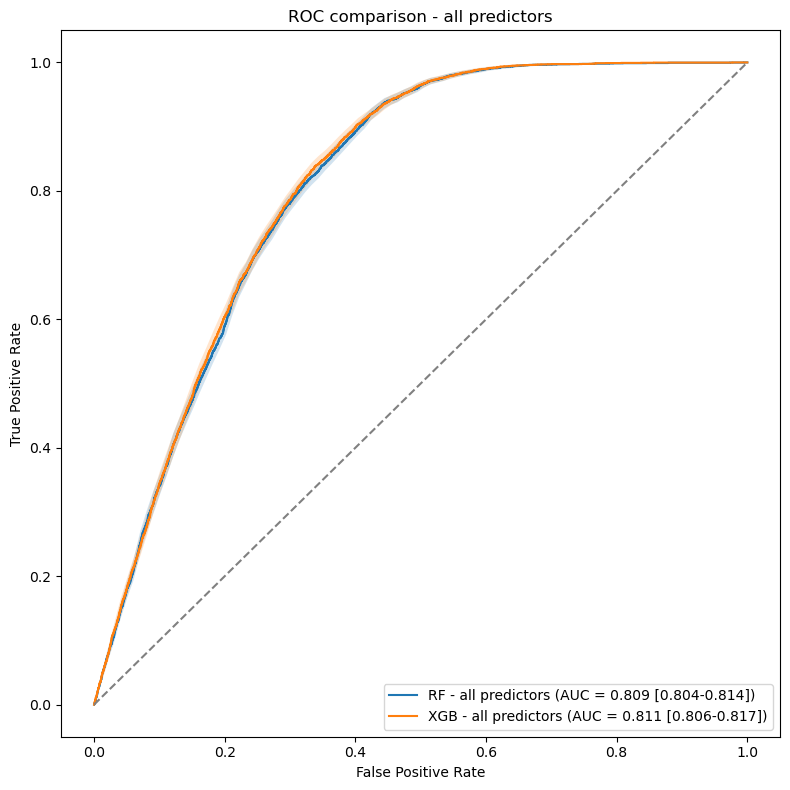

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(
    rf_metrics["fpr"],
    rf_metrics["tpr"],
    label=f"RF - all predictors (AUC = {rf_metrics['auc']:.3f} [{rf_metrics['auc_ci_lower']:.3f}-{rf_metrics['auc_ci_upper']:.3f}])",
)
ax.fill_between(
    rf_metrics["fpr_grid"],
    rf_metrics["tpr_lower"],
    rf_metrics["tpr_upper"],
    alpha=0.2,
)

ax.plot(
    xgb_metrics["fpr"],
    xgb_metrics["tpr"],
    label=f"XGB - all predictors (AUC = {xgb_metrics['auc']:.3f} [{xgb_metrics['auc_ci_lower']:.3f}-{xgb_metrics['auc_ci_upper']:.3f}])",
)
ax.fill_between(
    xgb_metrics["fpr_grid"],
    xgb_metrics["tpr_lower"],
    xgb_metrics["tpr_upper"],
    alpha=0.2,
)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("ROC comparison - all predictors")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT_DIR / "combined_roc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
combined_auc = pd.DataFrame([
    {
        "model": "Random Forest",
        "cv_auc": rf_grid.best_score_,
        "test_auc": rf_metrics["auc"],
        "accuracy": rf_metrics["accuracy"],
        "precision": rf_metrics["precision"],
        "recall": rf_metrics["recall"],
        "f1": rf_metrics["f1"],
    },
    {
        "model": "XGBoost",
        "cv_auc": xgb_grid.best_score_,
        "test_auc": xgb_metrics["auc"],
        "accuracy": xgb_metrics["accuracy"],
        "precision": xgb_metrics["precision"],
        "recall": xgb_metrics["recall"],
        "f1": xgb_metrics["f1"],
    },
])

combined_auc.to_csv(OUT_DIR / "combined_auc_metrics_table.csv", index=False)
combined_auc

,model,cv_auc,test_auc,accuracy,precision,recall,f1
0,Random Forest,0.815899,0.808920,0.689775,0.232500,0.812861,0.361578
1,XGBoost,0.816689,0.811232,0.664175,0.224107,0.855887,0.355206


In [28]:
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "rf_prob": rf_metrics["y_prob"],
    "xgb_prob": xgb_metrics["y_prob"],
    "rf_pred": rf_metrics["y_pred"],
    "xgb_pred": xgb_metrics["y_pred"],
})

pred_df.to_csv(OUT_DIR / "test_predictions.csv", index=False)
pred_df.head()

,y_true,rf_prob,xgb_prob,rf_pred,xgb_pred
0,0,0.768994,0.805274,1,1
1,1,0.745881,0.775586,1,1
2,1,0.454732,0.508804,0,1
3,0,0.551302,0.618811,1,1
4,0,0.787209,0.790465,1,1


In [29]:
run_summary = {
    "base_dir": str(BASE_DIR),
    "analysis_dir": str(ANALYSIS_DIR),
    "train_shape": list(df_train.shape),
    "test_shape": list(df_test.shape),
    "n_all_predictors": len(all_predictors),
    "all_predictors": all_predictors,
    "target": TARGET,
    "excluded_variables": sorted(list(EXCLUDE_VARS)),
}


run_summary["shap"] = {
    "random_forest": rf_shap["metadata"],
    "xgboost": xgb_shap["metadata"],
}

with open(OUT_DIR / "run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved run summary")
print("Main output folder:", OUT_DIR)

Saved run summary
Main output folder: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml/tree_models_python_all


In [30]:
print("\n====================================================")
print("All-predictors workflow completed")
print("====================================================")
print("Main output folder:", OUT_DIR)
print("Random Forest folder:", rf_out_dir)
print("XGBoost folder:", xgb_out_dir)
print("====================================================")


All-predictors workflow completed
Main output folder: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml/tree_models_python_all
Random Forest folder: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml/tree_models_python_all/random_forest
XGBoost folder: /rds/general/project/hda_25-26/live/TDS/fg520/TDS-Group-4/02_results/03_ml/tree_models_python_all/xgboost
